In [16]:
# Toutes les bibliothèques

import numpy as np  # Calcul numérique et manipulation des tableaux
import pandas as pd  # Manipulation et analyse des données
import matplotlib.pyplot as plt  # Visualisation graphique
import torch  # Bibliothèque principale PyTorch
import torchvision  # Outils de vision par ordinateur pour PyTorch
from torchvision import models  # Modèles pré-entraînés
from torch.utils.data import DataLoader, random_split  # Chargement et division des données
from torchvision import transforms  # Transformations appliquées aux images
import torch.nn as nn  # Modules pour construire les réseaux de neurones
import torch.nn.functional as F  # Fonctions d'activation et opérations du réseau
import torch.optim as optim  # Optimiseurs pour l'entraînement
from tqdm.auto import tqdm  # Barre de progression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report  # Métriques d'évaluation
import seaborn as sns  # Visualisation avancée
import random  # Génération de nombres aléatoires
from datetime import datetime  # Gestion des dates et heures

# Vérification du chargement des bibliothèques
print(" Tous les imports réussis!")

# Affichage de la version de PyTorch utilisée
print(f"PyTorch: {torch.__version__}")

# Affichage de la version de TorchVision utilisée
print(f"TorchVision: {torchvision.__version__}")

 Tous les imports réussis!
PyTorch: 2.5.1
TorchVision: 0.20.1


In [17]:
# Cellule 3 - Configuration GPU/CPU

# Sélection automatique du GPU (CUDA) si disponible, sinon utilisation du CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device utilisé: {device}")

# Définition d'une graine aléatoire pour garantir la reproductibilité des résultats
SEED = 42

# Initialisation de la graine pour PyTorch
torch.manual_seed(SEED)

# Initialisation de la graine pour le GPU si CUDA est disponible
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

# Initialisation des graines pour NumPy et random
np.random.seed(SEED)
random.seed(SEED)

# Liste des classes du dataset FashionMNIST
CLASSES = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
           'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# Affichage du nombre de classes
print(f"Nombre de classes: {len(CLASSES)}")

# Affichage des noms des classes
print(f"Classes: {CLASSES}")

Device utilisé: cpu
Nombre de classes: 10
Classes: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


In [19]:
# Cellule 4 - Data augmentation

# Transformations appliquées aux données d'entraînement
train_transform = transforms.Compose([
    # Retourne horizontalement l'image avec une probabilité de 50 %
    transforms.RandomHorizontalFlip(p=0.5),

    # Effectue une rotation aléatoire comprise entre -10° et +10°
    transforms.RandomRotation(10),

    # Conversion de l'image en tenseur PyTorch
    transforms.ToTensor(),

    # Normalisation des pixels dans l'intervalle [-1, 1]
    transforms.Normalize((0.5,), (0.5,))
])

# Transformations appliquées aux données de test
test_transform = transforms.Compose([
    # Conversion de l'image en tenseur PyTorch
    transforms.ToTensor(),

    # Normalisation des pixels avec les mêmes paramètres que l'entraînement
    transforms.Normalize((0.5,), (0.5,))
])

# Affichage des transformations définies
print(" Transformations définies")
print(f"Train transform: {train_transform}")
print(f"Test transform: {test_transform}")

 Transformations définies
Train transform: Compose(
    RandomHorizontalFlip(p=0.5)
    RandomRotation(degrees=[-10.0, 10.0], interpolation=nearest, expand=False, fill=0)
    ToTensor()
    Normalize(mean=(0.5,), std=(0.5,))
)
Test transform: Compose(
    ToTensor()
    Normalize(mean=(0.5,), std=(0.5,))
)


In [21]:
# Cellule 5 - Téléchargement et chargement du dataset FashionMNIST

print("Téléchargement de FashionMNIST...")

# Chargement du jeu de données d'entraînement avec les transformations définies
train_dataset = torchvision.datasets.FashionMNIST(
    root='data', train=True, download=True, transform=train_transform
)

# Chargement du jeu de données de test avec les transformations définies
test_dataset = torchvision.datasets.FashionMNIST(
    root='data', train=False, download=True, transform=test_transform
)

print(f" Dataset chargé!")
print(f"Train dataset taille: {len(train_dataset)}")
print(f"Test dataset taille: {len(test_dataset)}")

# Affichage des caractéristiques d'un exemple du dataset
image, label = train_dataset[0]

print(f"Image shape: {image.shape}")
print(f"Label: {label} ({CLASSES[label]})")

Téléchargement de FashionMNIST...
 Dataset chargé!
Train dataset taille: 60000
Test dataset taille: 10000
Image shape: torch.Size([1, 28, 28])
Label: 9 (Ankle boot)


In [23]:
# Cellule 6 - Création du jeu de validation

# Réservation de 10% des données d'entraînement pour la validation
val_size = int(0.1 * len(train_dataset))
train_size = len(train_dataset) - val_size

# Division du dataset d'entraînement en ensembles d'entraînement et de validation
# La graine SEED garantit la reproductibilité du découpage
train_dataset, val_dataset = random_split(
    train_dataset, 
    [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)

# Affichage des tailles des différents ensembles de données
print(f"Train size (after split): {len(train_dataset)}")
print(f"Validation size: {len(val_dataset)}")
print(f"Test size: {len(test_dataset)}")

Train size (after split): 48600
Validation size: 5400
Test size: 10000


In [24]:
# Cellule 7 - Création des DataLoaders

# Définition de la taille des lots (batch size)
BATCH_SIZE = 64

# Import du module platform pour détecter le système d'exploitation
import platform

# Gestion de compatibilité Windows : désactivation du multiprocessing
num_workers = 0 if platform.system() == 'Windows' else 2

# DataLoader pour l'ensemble d'entraînement (mélange des données activé)
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=num_workers
)

# DataLoader pour l'ensemble de validation (sans mélange)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=num_workers
)

# DataLoader pour l'ensemble de test (sans mélange)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=num_workers
)

# Affichage des informations sur les DataLoaders
print(f" DataLoaders créés")
print(f"Nombre de batches train: {len(train_loader)}")
print(f"Nombre de batches val: {len(val_loader)}")
print(f"Nombre de batches test: {len(test_loader)}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Num workers: {num_workers}")

 DataLoaders créés
Nombre de batches train: 760
Nombre de batches val: 85
Nombre de batches test: 157
Batch size: 64
Num workers: 0


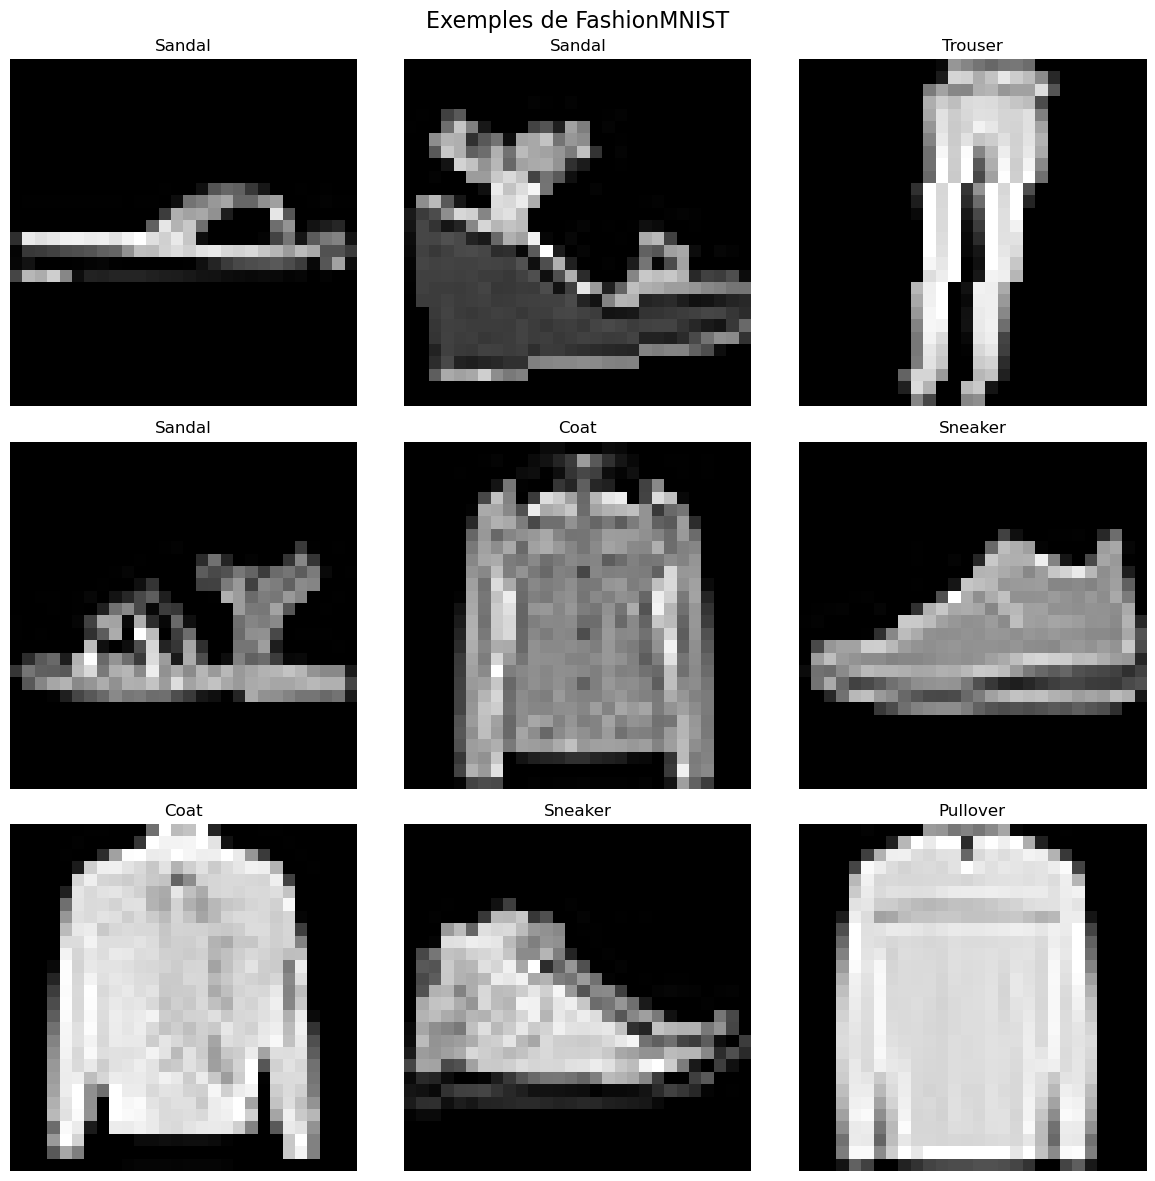

In [25]:
# Cellule 8 - Affichage d'échantillons du dataset FashionMNIST

# Création d'une figure avec une grille de 3x3 sous-graphiques
fig, axes = plt.subplots(3, 3, figsize=(12, 12))

# Affichage de 9 images aléatoires du dataset d'entraînement
for i in range(9):
    
    # Sélection aléatoire d'un indice dans le dataset
    idx = random.randint(0, len(train_dataset) - 1)
    
    # Récupération de l'image et de son label associé
    img, label = train_dataset[idx]
    
    # Vérification du format de l'image (cas potentiel après random_split)
    if isinstance(img, tuple):
        img = img[0]
    
    # Sélection de la position dans la grille (ligne, colonne)
    ax = axes[i // 3, i % 3]
    
    # Affichage de l'image en niveaux de gris
    ax.imshow(img.squeeze(), cmap='gray')
    
    # Ajout du titre correspondant à la classe de l'image
    ax.set_title(f"{CLASSES[label]}", fontsize=12)
    
    # Suppression des axes pour une meilleure lisibilité
    ax.axis('off')

# Titre global de la figure
plt.suptitle("Exemples de FashionMNIST", fontsize=16)

# Ajustement automatique des espacements
plt.tight_layout()

# Affichage de la figure
plt.show()

In [35]:
# Cellule 9 - Architecture du réseau (CNN amélioré pour FashionMNIST)

class FashionCNNImproved(nn.Module):
    
    def __init__(self, input_channels=1, num_classes=10, dropout_rate=0.3):
        super(FashionCNNImproved, self).__init__()
        
        # Bloc de convolution 1 : extraction des caractéristiques de base
        self.conv_block1 = nn.Sequential(
            nn.Conv2d(input_channels, 32, kernel_size=3, stride=1, padding=1),  # extraction des features
            nn.BatchNorm2d(32),                                                  # normalisation des activations
            nn.ReLU(),                                                           # fonction d'activation
            nn.Conv2d(32, 32, kernel_size=3, stride=1, padding=1),              # amélioration des features
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),                              # réduction de la dimension spatiale
            nn.Dropout2d(dropout_rate)                                           # régularisation
        )
        
        # Bloc de convolution 2 : extraction de features plus complexes
        self.conv_block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout2d(dropout_rate)
        )
        
        # Bloc de convolution 3 : extraction de features profondes
        self.conv_block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout2d(dropout_rate)
        )
        
        # Taille des features après les convolutions (128 canaux * 3x3)
        self.feature_size = 128 * 3 * 3
        
        # Classifieur fully-connected pour la décision finale
        self.classifier = nn.Sequential(
            nn.Flatten(),                               # aplatissement des features
            nn.Linear(self.feature_size, 256),          # couche dense 1
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(256, 128),                        # couche dense 2
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(128, num_classes)                 # couche de sortie (10 classes)
        )
    
    def forward(self, x):
        # Passage dans les blocs convolutionnels
        x = self.conv_block1(x)
        x = self.conv_block2(x)
        x = self.conv_block3(x)
        
        # Passage dans le classifieur
        x = self.classifier(x)
        return x


# Instanciation du modèle et envoi sur le device (CPU ou GPU)
model = FashionCNNImproved().to(device)

# Affichage de l'architecture complète du modèle
print(model)

# Affichage du nombre total de paramètres entraînables du modèle
print(f"\nNombre total de paramètres: {sum(p.numel() for p in model.parameters()):,}")

FashionCNNImproved(
  (conv_block1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout2d(p=0.3, inplace=False)
  )
  (conv_block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mo

In [36]:
# Cellule 10 - Fonctions utilitaires

# Fonction pour calculer l'accuracy (précision) en pourcentage
def accuracy_fn(y_true, y_pred):
    """Calcule l'accuracy en pourcentage"""
    # Nombre de prédictions correctes
    correct = torch.eq(y_true, y_pred).sum().item()
    
    # Taux de bonnes prédictions en %
    return (correct / len(y_pred)) * 100


# Fonction d'entraînement sur une époque
def train_one_epoch(model, train_loader, criterion, optimizer, device):
    """Entraîne le modèle pour une époque"""
    
    model.train()  # mode entraînement (active dropout, batchnorm)
    
    running_loss = 0.0  # accumulation des pertes
    running_acc = 0.0   # accumulation des accuracies
    
    # Boucle sur tous les batches d'entraînement
    for batch_idx, (data, target) in enumerate(train_loader):
        
        # Envoi des données sur CPU ou GPU
        data, target = data.to(device), target.to(device)
        
        # Réinitialisation des gradients
        optimizer.zero_grad()
        
        # Forward pass (prédiction du modèle)
        output = model(data)
        
        # Calcul de la perte
        loss = criterion(output, target)
        
        # Backpropagation
        loss.backward()
        
        # Mise à jour des poids
        optimizer.step()
        
        # Accumulation des métriques
        running_loss += loss.item()
        running_acc += accuracy_fn(target, output.argmax(dim=1))
        
        # Affichage de la progression toutes les 100 itérations
        if (batch_idx + 1) % 100 == 0:
            print(f"  Batch {batch_idx+1}/{len(train_loader)} - Loss: {loss.item():.4f}")
    
    # Moyenne des pertes et accuracy sur l'époque
    avg_loss = running_loss / len(train_loader)
    avg_acc = running_acc / len(train_loader)
    
    return avg_loss, avg_acc


# Fonction d'évaluation du modèle
def evaluate(model, data_loader, criterion, device):
    """Évalue le modèle sur un dataset (validation/test)"""
    
    model.eval()  # mode évaluation (désactive dropout)
    
    total_loss = 0.0
    total_acc = 0.0
    
    all_preds = []     # stockage des prédictions
    all_targets = []   # stockage des vraies valeurs
    
    # Désactivation du calcul des gradients pour accélérer
    with torch.no_grad():
        for data, target in data_loader:
            
            # Envoi sur device
            data, target = data.to(device), target.to(device)
            
            # Prédiction
            output = model(data)
            
            # Calcul de la loss
            loss = criterion(output, target)
            
            # Accumulation des métriques
            total_loss += loss.item()
            total_acc += accuracy_fn(target, output.argmax(dim=1))
            
            # Sauvegarde des résultats
            all_preds.extend(output.argmax(dim=1).cpu().numpy())
            all_targets.extend(target.cpu().numpy())
    
    # Moyennes finales
    avg_loss = total_loss / len(data_loader)
    avg_acc = total_acc / len(data_loader)
    
    return avg_loss, avg_acc, all_preds, all_targets


# Confirmation que les fonctions sont prêtes
print(" Fonctions définies")

 Fonctions définies


In [38]:
# Cellule 11 - Initialisation de l'optimiseur et de la fonction de perte

# Fonction de perte pour un problème de classification multi-classes
# CrossEntropyLoss combine Softmax + Negative Log Likelihood
criterion = nn.CrossEntropyLoss()

# Optimiseur Adam pour mettre à jour les poids du modèle
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Scheduler pour réduire automatiquement le learning rate si la loss stagne
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',       # on surveille la loss (à minimiser)
    patience=2,       # nombre d'époques sans amélioration avant réduction
    # verbose=True      # affiche les changements de learning rate
)

# Confirmation de la configuration
print(" Optimiseur et loss function configurés")

# Affichage du learning rate initial
print(f"Learning rate initial: {optimizer.param_groups[0]['lr']}")

 Optimiseur et loss function configurés
Learning rate initial: 0.001


In [39]:
# Cellule 12 - Entraînement du modèle (phase finale)

# Nombre d'époques d'entraînement
NUM_EPOCHS = 10  

# Listes pour stocker les métriques au fil des époques
train_losses = []
val_losses = []
train_accs = []
val_accs = []

print("Début de l'entraînement...")
print("=" * 60)

# Boucle principale d'entraînement sur plusieurs époques
for epoch in range(NUM_EPOCHS):
    
    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
    print("-" * 40)
    
    # Phase d'entraînement sur une époque
    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, device
    )
    
    # Phase de validation (évaluation sur données non vues)
    val_loss, val_acc, _, _ = evaluate(
        model, val_loader, criterion, device
    )
    
    # Mise à jour automatique du learning rate selon la validation loss
    scheduler.step(val_loss)
    
    # Sauvegarde des métriques pour analyse après entraînement
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    
    # Affichage des résultats de l'époque courante
    print(f" Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f" Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")
    print(f" Learning rate: {optimizer.param_groups[0]['lr']:.6f}")

print("\n" + "=" * 60)
print(" Entraînement terminé!")

Début de l'entraînement...

Epoch 1/10
----------------------------------------
  Batch 100/760 - Loss: 0.6070
  Batch 200/760 - Loss: 0.7746
  Batch 300/760 - Loss: 0.6425
  Batch 400/760 - Loss: 0.5997
  Batch 500/760 - Loss: 0.5515
  Batch 600/760 - Loss: 0.5530
  Batch 700/760 - Loss: 0.4822
 Train Loss: 0.6814 | Train Acc: 75.05%
 Val Loss: 0.4003 | Val Acc: 85.43%
 Learning rate: 0.001000

Epoch 2/10
----------------------------------------
  Batch 100/760 - Loss: 0.5303
  Batch 200/760 - Loss: 0.4636
  Batch 300/760 - Loss: 0.4679
  Batch 400/760 - Loss: 0.3298
  Batch 500/760 - Loss: 0.5001
  Batch 600/760 - Loss: 0.3933
  Batch 700/760 - Loss: 0.3094
 Train Loss: 0.4463 | Train Acc: 83.74%
 Val Loss: 0.3368 | Val Acc: 87.19%
 Learning rate: 0.001000

Epoch 3/10
----------------------------------------
  Batch 100/760 - Loss: 0.5038
  Batch 200/760 - Loss: 0.3435
  Batch 300/760 - Loss: 0.4718
  Batch 400/760 - Loss: 0.4678
  Batch 500/760 - Loss: 0.4222
  Batch 600/760 - Loss:

In [40]:
# Cellule 13 - Test final (évaluation sur données jamais vues)

# Évaluation du modèle sur le jeu de test
print("Évaluation sur le jeu de test...")

test_loss, test_acc, test_preds, test_targets = evaluate(
    model, test_loader, criterion, device
)

# Affichage des résultats finaux du modèle
print(f"\n RÉSULTATS FINAUX:")
print(f"Loss sur le test: {test_loss:.4f}")
print(f"Accuracy sur le test: {test_acc:.2f}%")

Évaluation sur le jeu de test...

 RÉSULTATS FINAUX:
Loss sur le test: 0.2435
Accuracy sur le test: 91.36%


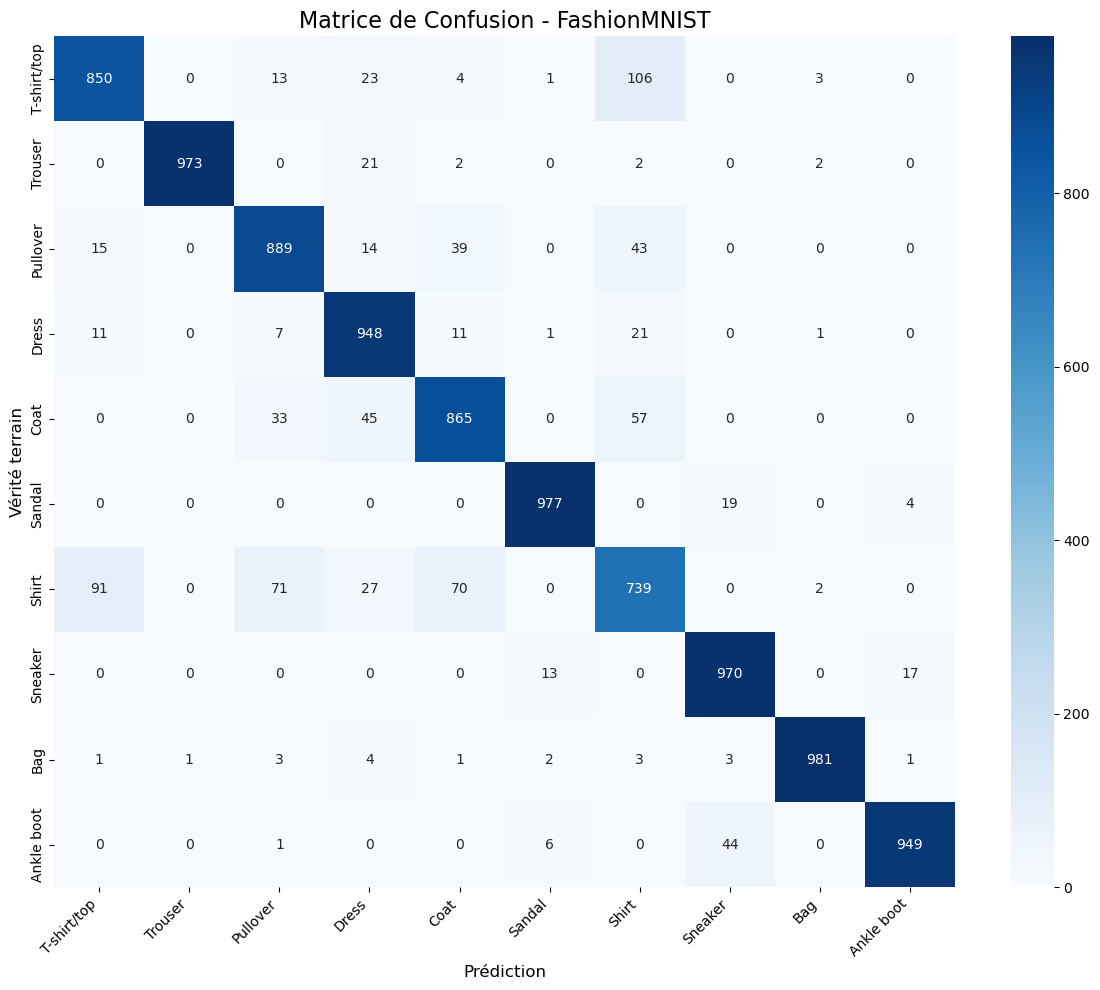

In [41]:
# Cellule 14 - Visualisation des résultats (Matrice de confusion)

# Calcul de la matrice de confusion entre les vraies classes et les prédictions du modèle
cm = confusion_matrix(test_targets, test_preds)

# Création de la figure avec une taille adaptée pour une bonne lisibilité
plt.figure(figsize=(12, 10))

# Affichage de la matrice de confusion sous forme de heatmap
# annot=True : affiche les valeurs dans chaque case
# fmt='d' : format entier
# cmap='Blues' : palette de couleurs bleues
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=CLASSES,
    yticklabels=CLASSES
)

# Titre du graphique
plt.title('Matrice de Confusion - FashionMNIST', fontsize=16)

# Label de l'axe X (prédictions du modèle)
plt.xlabel('Prédiction', fontsize=12)

# Label de l'axe Y (vraies classes)
plt.ylabel('Vérité terrain', fontsize=12)

# Rotation des labels de l'axe X pour une meilleure lisibilité
plt.xticks(rotation=45, ha='right')

# Ajustement automatique des espaces pour éviter les chevauchements
plt.tight_layout()

# Affichage du graphique
plt.show()

In [42]:
# Cellule 15 - Rapport détaillé

# Affichage d'un titre pour le rapport de classification
print(" RAPPORT DE CLASSIFICATION:")

# Séparateur visuel pour améliorer la lisibilité du rapport
print("=" * 60)

# Génération du rapport de classification :
# - précision (precision)
# - rappel (recall)
# - F1-score
# - support (nombre d'exemples par classe)
print(classification_report(
    test_targets,
    test_preds,
    target_names=CLASSES
))

 RAPPORT DE CLASSIFICATION:
              precision    recall  f1-score   support

 T-shirt/top       0.88      0.85      0.86      1000
     Trouser       1.00      0.97      0.99      1000
    Pullover       0.87      0.89      0.88      1000
       Dress       0.88      0.95      0.91      1000
        Coat       0.87      0.86      0.87      1000
      Sandal       0.98      0.98      0.98      1000
       Shirt       0.76      0.74      0.75      1000
     Sneaker       0.94      0.97      0.95      1000
         Bag       0.99      0.98      0.99      1000
  Ankle boot       0.98      0.95      0.96      1000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



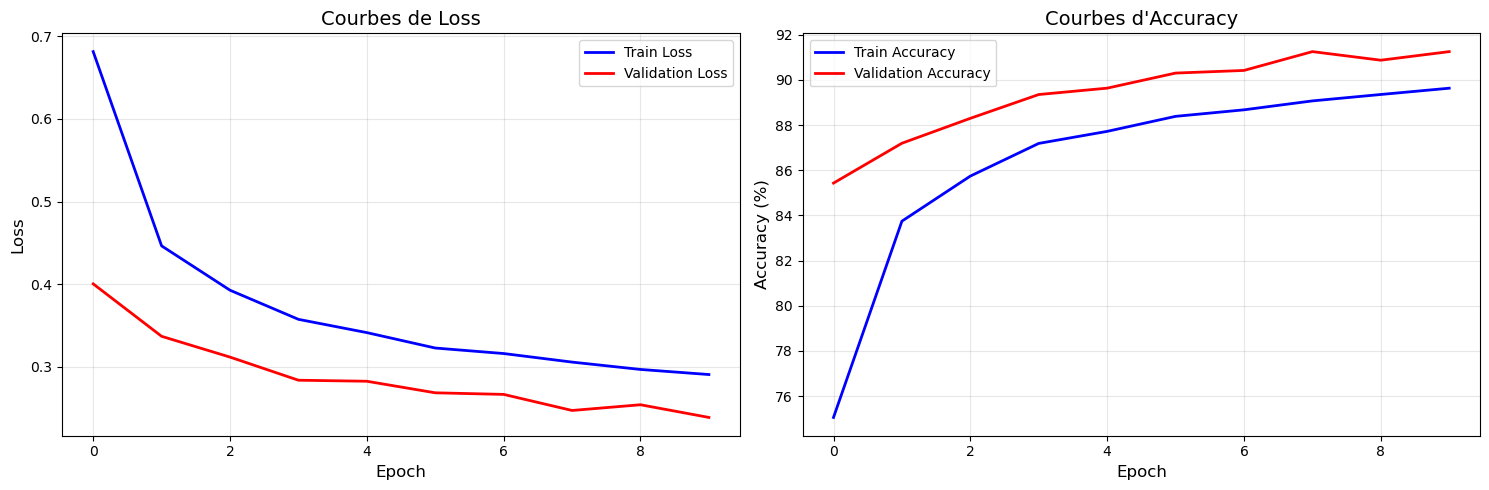


 Meilleure accuracy validation: 91.25%
 Meilleure accuracy test: 91.36%


In [43]:
# Cellule 16 - Visualisation des courbes d'apprentissage

# Création d'une figure avec 2 sous-graphiques (loss et accuracy)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Tracé de la courbe de loss sur l'ensemble d'entraînement
axes[0].plot(train_losses, 'b-', label='Train Loss', linewidth=2)

# Tracé de la courbe de loss sur l'ensemble de validation
axes[0].plot(val_losses, 'r-', label='Validation Loss', linewidth=2)

# Définition du label de l'axe X pour la loss
axes[0].set_xlabel('Epoch', fontsize=12)

# Définition du label de l'axe Y pour la loss
axes[0].set_ylabel('Loss', fontsize=12)

# Définition du titre du graphique de loss
axes[0].set_title('Courbes de Loss', fontsize=14)

# Affichage de la légende
axes[0].legend()

# Activation de la grille pour améliorer la lisibilité
axes[0].grid(True, alpha=0.3)

# Tracé de la courbe d'accuracy sur l'ensemble d'entraînement
axes[1].plot(train_accs, 'b-', label='Train Accuracy', linewidth=2)

# Tracé de la courbe d'accuracy sur l'ensemble de validation
axes[1].plot(val_accs, 'r-', label='Validation Accuracy', linewidth=2)

# Définition du label de l'axe X pour l'accuracy
axes[1].set_xlabel('Epoch', fontsize=12)

# Définition du label de l'axe Y pour l'accuracy
axes[1].set_ylabel('Accuracy (%)', fontsize=12)

# Définition du titre du graphique d'accuracy
axes[1].set_title("Courbes d'Accuracy", fontsize=14)

# Affichage de la légende
axes[1].legend()

# Activation de la grille pour améliorer la lisibilité
axes[1].grid(True, alpha=0.3)

# Ajustement automatique de la disposition des graphiques
plt.tight_layout()

# Affichage de la figure
plt.show()

# Affichage de la meilleure accuracy obtenue sur la validation
print(f"\n Meilleure accuracy validation: {max(val_accs):.2f}%")

# Affichage de la meilleure accuracy sur le test
print(f" Meilleure accuracy test: {test_acc:.2f}%")

In [44]:
# Cellule 17 - Sauvegarde du modèle et des résultats

# Génération d'un timestamp pour rendre les fichiers uniques
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# Définition du chemin de sauvegarde du modèle
model_path = f'fashion_mnist_model_{timestamp}.pth'

# Sauvegarde complète du modèle et de ses informations d'entraînement
torch.save({
    'model_state_dict': model.state_dict(),          # poids du modèle entraîné
    'optimizer_state_dict': optimizer.state_dict(),  # état de l'optimiseur
    'test_accuracy': test_acc,                       # accuracy sur test
    'test_loss': test_loss,                          # loss sur test
    'classes': CLASSES                               # noms des classes
}, model_path)

# Affichage de confirmation de sauvegarde du modèle
print(f"Modèle sauvegardé: {model_path}")

# Import de json pour sauvegarder les résultats
import json

# Création d'un dictionnaire contenant les métriques principales
results = {
    'test_accuracy': float(test_acc),          # accuracy finale sur test
    'test_loss': float(test_loss),             # loss finale sur test
    'best_val_accuracy': float(max(val_accs)), # meilleure accuracy validation
    'epochs': NUM_EPOCHS,                      # nombre d'époques
    'batch_size': BATCH_SIZE                   # taille des batches
}

# Sauvegarde des résultats dans un fichier JSON
with open(f'results_{timestamp}.json', 'w') as f:
    json.dump(results, f, indent=4)

# Affichage de confirmation de sauvegarde des résultats
print("Résultats sauvegardés")

Modèle sauvegardé: fashion_mnist_model_20260622_000233.pth
Résultats sauvegardés


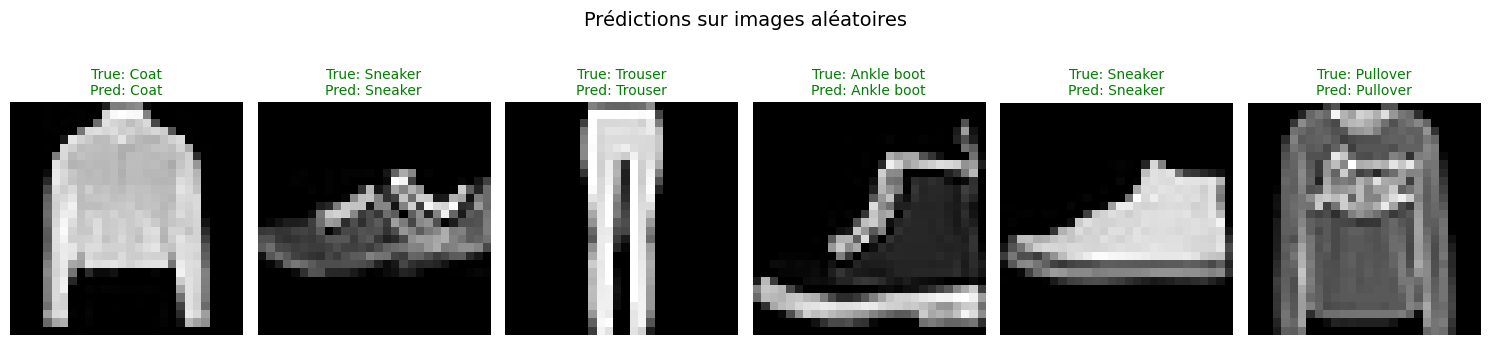

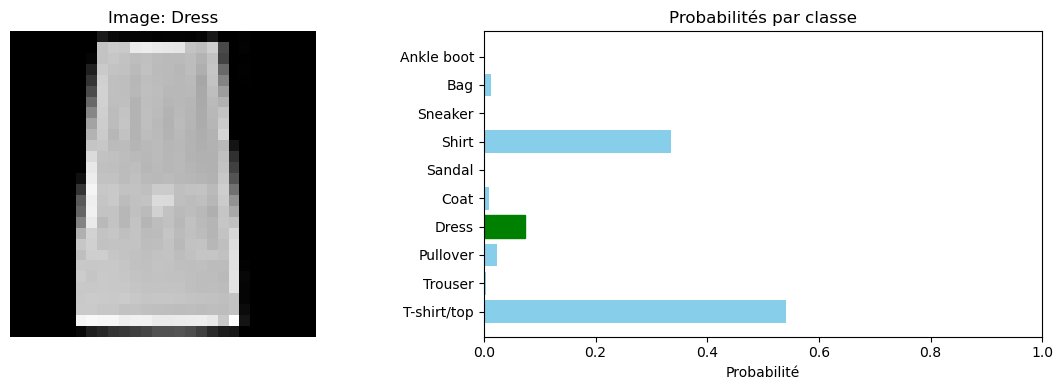

In [45]:
# Cellule 17 - Test sur des images aléatoires et visualisation des prédictions

# Fonction de prédiction sur des images aléatoires avec visualisation
def predict_random_images(model, dataset, num_images=5):
    """Prédit sur des images aléatoires et affiche les résultats"""
    
    # Mise du modèle en mode évaluation
    model.eval()
    
    # Sélection aléatoire d'indices dans le dataset
    indices = random.sample(range(len(dataset)), num_images)
    
    # Création de la figure pour l'affichage des images
    fig, axes = plt.subplots(1, num_images, figsize=(15, 4))
    
    # Désactivation du calcul des gradients pour accélérer l'inférence
    with torch.no_grad():
        
        # Parcours des images sélectionnées
        for i, idx in enumerate(indices):
            
            # Récupération de l'image et de son label réel
            img, true_label = dataset[idx]
            
            # Préparation de l'image pour le modèle (ajout batch dimension + device)
            if isinstance(img, tuple):
                img_tensor = img[0].unsqueeze(0).to(device)
            else:
                img_tensor = img.unsqueeze(0).to(device)
            
            # Prédiction du modèle
            output = model(img_tensor)
            pred_label = output.argmax(dim=1).item()
            
            # Affichage de l'image
            axes[i].imshow(img.squeeze(), cmap='gray')
            
            # Couleur verte si correct, rouge si incorrect
            color = 'green' if pred_label == true_label else 'red'
            
            # Titre avec vrai label et prédiction
            axes[i].set_title(
                f'True: {CLASSES[true_label]}\nPred: {CLASSES[pred_label]}',
                color=color,
                fontsize=10
            )
            
            # Suppression des axes
            axes[i].axis('off')
    
    # Titre global
    plt.suptitle('Prédictions sur images aléatoires', fontsize=14)
    
    # Ajustement automatique de la mise en page
    plt.tight_layout()
    
    # Affichage final
    plt.show()


# Test du modèle sur des images aléatoires du dataset de test
predict_random_images(model, test_dataset, num_images=6)


# Fonction pour afficher les probabilités de prédiction
def show_prediction_probs(model, dataset, idx):
    """Affiche les probabilités de prédiction pour une image donnée"""
    
    # Mise en mode évaluation
    model.eval()
    
    # Récupération de l'image et du label réel
    img, true_label = dataset[idx]
    
    # Désactivation du gradient pour l'inférence
    with torch.no_grad():
        
        # Préparation de l'image pour le modèle
        if isinstance(img, tuple):
            img_tensor = img[0].unsqueeze(0).to(device)
        else:
            img_tensor = img.unsqueeze(0).to(device)
        
        # Prédiction du modèle
        output = model(img_tensor)
        
        # Conversion des sorties en probabilités
        probs = torch.softmax(output, dim=1).squeeze().cpu().numpy()
    
    # Création de la figure
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    # Affichage de l'image originale
    ax1.imshow(img.squeeze(), cmap='gray')
    ax1.set_title(f'Image: {CLASSES[true_label]}')
    ax1.axis('off')
    
    # Affichage des probabilités par classe
    bars = ax2.barh(CLASSES, probs, color='skyblue')
    
    # Mise en évidence de la vraie classe
    bars[true_label].set_color('green')
    
    # Limite de l'axe X entre 0 et 1
    ax2.set_xlim(0, 1)
    
    # Label de l'axe X
    ax2.set_xlabel('Probabilité')
    
    # Titre du graphique
    ax2.set_title('Probabilités par classe')
    
    # Ajustement de la mise en page
    plt.tight_layout()
    
    # Affichage final
    plt.show()


# Exemple de test sur une image du dataset
show_prediction_probs(model, test_dataset, idx=42)